<a href="https://colab.research.google.com/github/Mohitraj4707/data-analytics/blob/main/Sales_Forecasting_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sales Forecasting using LSTM

A complete, Colab-ready deep learning project that forecasts daily sales using a
Long Short-Term Memory (LSTM) network.

**Pipeline:**
1. Generate / load a sales time series
2. Preprocess (scale + create sliding-window sequences)
3. Build and train an LSTM model
4. Evaluate (RMSE, MAE, MAPE) and visualize predictions
5. Forecast future sales beyond the dataset
6. Save the model + scaler, and reload them with a reusable prediction function

> Runs end-to-end on Google Colab's free tier (CPU is fine, GPU is faster).


In [ ]:
# 1. Setup
!pip install -q tensorflow scikit-learn joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import joblib

np.random.seed(42)
tf.random.set_seed(42)


## 2. Dataset

This project ships with a **synthetic but realistic** daily sales generator
(trend + weekly seasonality + yearly seasonality + promotions + noise), so the
notebook always runs without needing an external download or API key.

**To use your own data instead:** upload a CSV with a `date` and `sales`
column, then replace the `df = generate_sales_data()` line with:
```python
df = pd.read_csv('/content/your_sales_file.csv', parse_dates=['date'])
df = df[['date', 'sales']].sort_values('date').reset_index(drop=True)
```
Everything downstream (scaling, sequencing, model, forecasting) works unchanged.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import joblib

np.random.seed(42)
tf.random.set_seed(42)

# 2a. Synthetic daily sales generator
def generate_sales_data(n_days=1460, start_date='2021-01-01'):
    dates = pd.date_range(start=start_date, periods=n_days, freq='D')
    t = np.arange(n_days)

    trend = 50 + 0.05 * t                                   # slow upward trend
    yearly_season = 15 * np.sin(2 * np.pi * t / 365.25)      # yearly cycle
    weekly_season = 10 * np.sin(2 * np.pi * t / 7)           # weekly cycle
    weekend_boost = np.where(pd.Series(dates).dt.dayofweek.isin([5, 6]), 8, 0)

    # Occasional promo spikes
    promo = np.zeros(n_days)
    promo_days = np.random.choice(n_days, size=n_days // 30, replace=False)
    promo[promo_days] = np.random.uniform(15, 30, size=len(promo_days))

    noise = np.random.normal(0, 4, n_days)

    sales = trend + yearly_season + weekly_season + weekend_boost + promo + noise
    sales = np.clip(sales, a_min=5, a_max=None)

    return pd.DataFrame({'date': dates, 'sales': sales})

df = pd.read_csv('/content/archive (4).zip', compression='zip', encoding='latin1', parse_dates=['Order Date'])
print(df.columns)
df = df[['Order Date', 'Sales']].sort_values('Order Date').reset_index(drop=True)
df.rename(columns={'Order Date': 'date', 'Sales': 'sales'}, inplace=True)
print(df.shape)
df.head()

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')
(2121, 2)


,date,sales
0,2014-01-06,2573.820
1,2014-01-07,76.728
2,2014-01-10,51.940
3,2014-01-11,9.940
4,2014-01-13,545.940


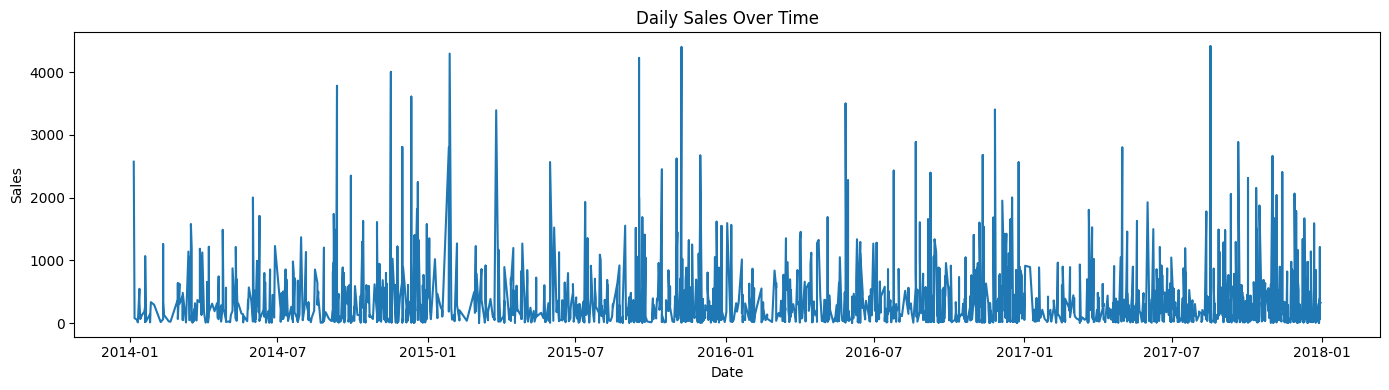

In [ ]:
# 2b. Visualize raw series
plt.figure(figsize=(14, 4))
plt.plot(df['date'], df['sales'])
plt.title('Daily Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()


## 3. Preprocessing

LSTMs need:
- Values scaled to a small range (`MinMaxScaler`, 0-1) so training is stable.
- A **sliding window** of past `LOOKBACK` days as input, predicting the next day's sales.


In [ ]:
# 3a. Scale
LOOKBACK = 30       # days of history the model sees
TEST_DAYS = 180     # holdout period for honest evaluation

sales_values = df['sales'].values.reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(sales_values)

def create_sequences(data, lookback):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled, LOOKBACK)
X = X.reshape((X.shape[0], X.shape[1], 1))   # [samples, timesteps, features]
print('X shape:', X.shape, ' y shape:', y.shape)


X shape: (2091, 30, 1)  y shape: (2091,)


In [ ]:
# 3b. Chronological train/test split (never shuffle time series!)
split_idx = len(X) - TEST_DAYS

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print('Train:', X_train.shape, 'Test:', X_test.shape)


Train: (1911, 30, 1) Test: (180, 30, 1)


## 4. Build the LSTM Model

A stacked LSTM with dropout for regularization. Kept small on purpose so it
trains quickly on Colab CPU; feel free to widen it once the pipeline works.


In [ ]:
# 4a. Model architecture
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(LOOKBACK, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 4b. Train
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0143 - mae: 0.0742 - val_loss: 0.0136 - val_mae: 0.0758
Epoch 2/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 107ms/step - loss: 0.0135 - mae: 0.0734 - val_loss: 0.0137 - val_mae: 0.0797
Epoch 3/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 0.0135 - mae: 0.0741 - val_loss: 0.0136 - val_mae: 0.0790
Epoch 4/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0136 - mae: 0.0741 - val_loss: 0.0136 - val_mae: 0.0781
Epoch 5/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0135 - mae: 0.0740 - val_loss: 0.0135 - val_mae: 0.0748
Epoch 6/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.0134 - mae: 0.0738 - val_loss: 0.0135 - val_mae: 0.0758
Epoch 7/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0135 - mae: 0.0738 - val_loss: 0.0136 - val_mae: 0.0771
Epoch 8/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0134 - mae: 0.0740 - val_loss: 0.0135 - val_mae: 0.0749
Epoch 9/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - l

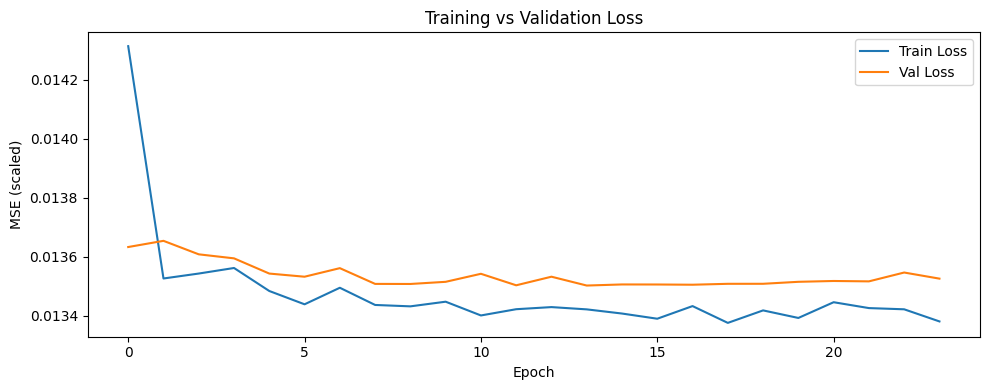

In [ ]:
# 4c. Loss curves
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE (scaled)')
plt.legend()
plt.tight_layout()
plt.show()


## 5. Evaluate on the Test Set

Predictions and targets are inverse-transformed back to real sales units
before computing metrics, so RMSE/MAE are interpretable (e.g. "off by ~4 units/day").


In [ ]:
# 5a. Predict + inverse-transform
y_pred_scaled = model.predict(X_test)

y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_actual = scaler.inverse_transform(y_pred_scaled)

rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mae = mean_absolute_error(y_test_actual, y_pred_actual)
mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100

print(f'RMSE: {rmse:.2f}')
print(f'MAE:  {mae:.2f}')
print(f'MAPE: {mape:.2f}%')


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step
RMSE: 417.05
MAE:  309.57
MAPE: 814.75%


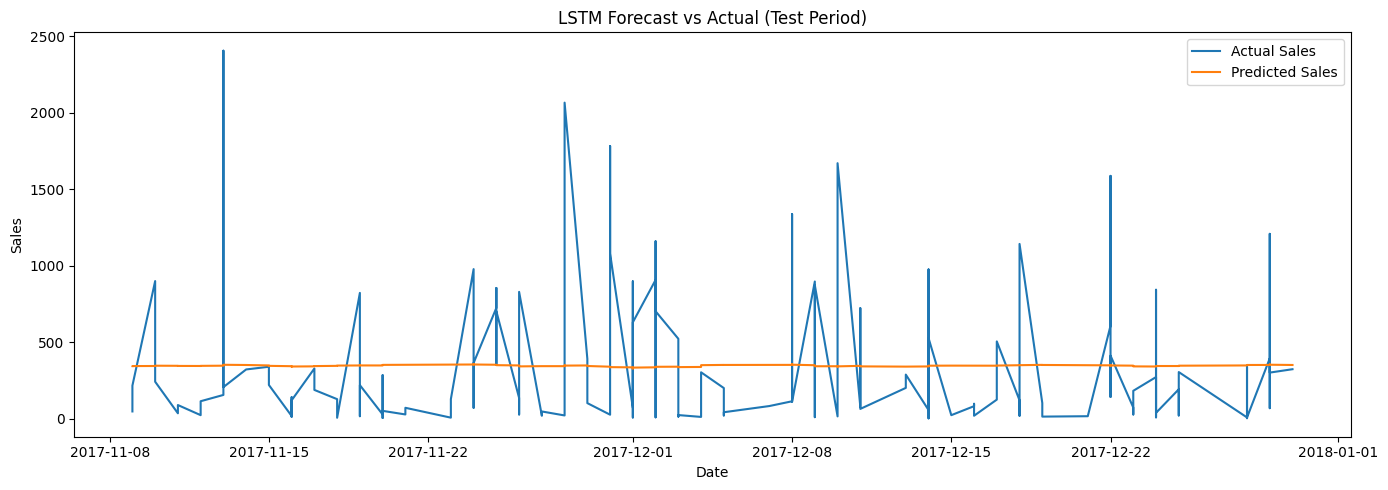

In [ ]:
# 5b. Actual vs Predicted plot
test_dates = df['date'].values[-TEST_DAYS:]

plt.figure(figsize=(14, 5))
plt.plot(test_dates, y_test_actual, label='Actual Sales')
plt.plot(test_dates, y_pred_actual, label='Predicted Sales')
plt.title('LSTM Forecast vs Actual (Test Period)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()


## 6. Forecast Beyond the Dataset (Multi-Step)

To predict `N` days into the future, we feed the model its own prior
predictions recursively — a standard approach for autoregressive forecasting
with a fixed lookback window.


In [ ]:
# 6a. Recursive multi-step forecast function
def forecast_future(model, scaler, last_sequence_scaled, n_future, lookback=LOOKBACK):
    """
    last_sequence_scaled: 1D array of the most recent `lookback` scaled values
    Returns: 1D array of `n_future` forecasted sales values (real units)
    """
    seq = last_sequence_scaled.copy().reshape(1, lookback, 1)
    preds_scaled = []

    for _ in range(n_future):
        next_val = model.predict(seq, verbose=0)[0, 0]
        preds_scaled.append(next_val)
        seq = np.append(seq[:, 1:, :], [[[next_val]]], axis=1)

    preds_scaled = np.array(preds_scaled).reshape(-1, 1)
    return scaler.inverse_transform(preds_scaled).flatten()

N_FUTURE = 30
last_window = scaled[-LOOKBACK:, 0]
future_sales = forecast_future(model, scaler, last_window, N_FUTURE)

future_dates = pd.date_range(start=df['date'].iloc[-1] + pd.Timedelta(days=1), periods=N_FUTURE)
forecast_df = pd.DataFrame({'date': future_dates, 'forecast_sales': future_sales})
forecast_df.head()


,date,forecast_sales
0,2017-12-31,349.298401
1,2018-01-01,348.132355
2,2018-01-02,347.221924
3,2018-01-03,346.563599
4,2018-01-04,346.024017


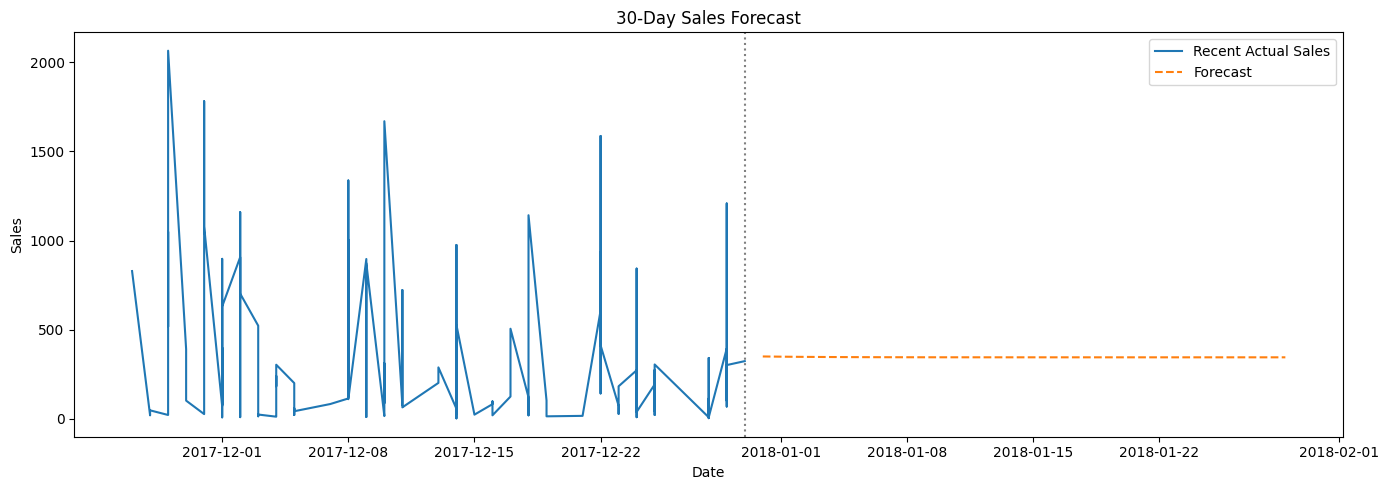

In [ ]:
# 6b. Plot history + forecast
plt.figure(figsize=(14, 5))
plt.plot(df['date'].iloc[-120:], df['sales'].iloc[-120:], label='Recent Actual Sales')
plt.plot(forecast_df['date'], forecast_df['forecast_sales'], label='Forecast', linestyle='--')
plt.axvline(df['date'].iloc[-1], color='gray', linestyle=':')
plt.title(f'{N_FUTURE}-Day Sales Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()


## 7. Save the Model + Scaler for Reuse

Saving both the trained model *and* the fitted scaler is essential — without
the exact same scaler, inverse-transforming predictions later will be wrong.


In [ ]:
# 7a. Save
model.save('sales_lstm_model.keras')
joblib.dump(scaler, 'sales_scaler.pkl')
print('Saved: sales_lstm_model.keras, sales_scaler.pkl')

# In Colab, download them or copy to Google Drive:
# from google.colab import files
# files.download('sales_lstm_model.keras')
# files.download('sales_scaler.pkl')


Saved: sales_lstm_model.keras, sales_scaler.pkl


In [ ]:
# 7b. Reusable load + predict function (use this in a fresh session/app)
def load_and_forecast(model_path, scaler_path, recent_sales, n_future=30, lookback=LOOKBACK):
    """
    recent_sales: 1D array-like of at least `lookback` most recent REAL sales values
    Returns: 1D numpy array of `n_future` forecasted sales values (real units)
    """
    loaded_model = load_model(model_path)
    loaded_scaler = joblib.load(scaler_path)

    recent_sales = np.array(recent_sales).reshape(-1, 1)[-lookback:]
    recent_scaled = loaded_scaler.transform(recent_sales).flatten()

    return forecast_future(loaded_model, loaded_scaler, recent_scaled, n_future, lookback)

# Example usage:
recent_actuals = df['sales'].values[-LOOKBACK:]
demo_forecast = load_and_forecast('sales_lstm_model.keras', 'sales_scaler.pkl', recent_actuals, n_future=14)
print(demo_forecast)


[349.2984  348.13235 347.22192 346.5636  346.02402 345.60617 345.29324
 345.06796 344.90756 344.784   344.72333 344.66275 344.6133  344.58258]


## 8. Next Steps / Ideas to Extend

- **Add features**: promotions, holidays, price, weather as extra input channels (multivariate LSTM).
- **Try alternatives**: GRU, 1D-CNN + LSTM hybrid, or a Transformer-based forecaster for comparison.
- **Hyperparameter tuning**: lookback window size, number of LSTM units/layers, batch size.
- **Walk-forward validation**: retrain/evaluate on rolling windows instead of a single train/test split, for a more robust performance estimate.
- **Deploy**: wrap `load_and_forecast()` in a small Flask/FastAPI endpoint or Streamlit app for a live demo.
